# Data Science and Analytics Group Assignment
## Group no 6
**Members:**
* Aamna Arif (40503414)
* Atharva Uday Kalase (40509608)
* Alpaycan Cabbar (40507357)
* Krishna Kumar Narendran (40504027)
* Tushar Chopra (40508526)
---------

## Data for analysis - IMDB Movie Dataset
**Regression:**
- **Analysis Questions 1 -** To what extent is a movie’s IMDb score associated with indicators of popularity (Facebook likes) and selected production characteristics such as budget, runtime, and year of release?
- **Column analyzed:** imdb_score, movie_facebook_likes, budget, duration, title_year

**Hypothesis Testing ANOVA**
- **Analysis Questions 2 -** Do average IMDb scores differ significantly across movie genres?
- **Column analyzed:** imdb_score, genres

**Hypothesis Testing**
- **Analysis Questions 3 -** Is there a significant difference in IMDb scores between movies with high and low levels of social media popularity?
- **Column analyzed:** imdb_score, movie_facebook_likes

---
# Section 1 - Exploratory Data Analysis (EDA) -- (PPT Slide 2-3)
## 1.1 Setup and Data Loading
First, we import the necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`seaborn`, `matplotlib`), and statistical analysis (`scipy`, `statsmodels`).

In [ ]:
# --- Data & Math ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics & Modeling ---
import scipy.stats as stats
from scipy.stats import shapiro, levene, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Professional Plotting Setup
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = [10, 6]

--------------
## 1.2 Initial Data Inspection
In this step, we load the dataset `IMDBMovieScores.csv` and perform an initial inspection to understand the structure, column names, and data types.

In [ ]:
IMDB_dataset="IMDBMovieScores.csv"
df=pd.read_csv(IMDB_dataset)
df.head(5)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


--------------
### 1.2.1 Technical Metadata
We use `df.info()` to understand the data types, the number of entries, and identify columns with missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

--------------
### 1.2.2 Descriptive Statistics
This summary provides insights into the central tendency, dispersion, and range of the numerical features in the dataset.

In [ ]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [ ]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

## 1.2.3. Data Cleaning
We need to identify and address missing values (NaNs) to ensure the validity of our statistical tests.

In [ ]:
df.isna().sum()

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
genres,0


In the next step we drop all the movies where either the budget or the title_year is missing.

In [ ]:
df=df.dropna(subset=['budget', 'title_year'])
df.shape

(4543, 28)

This step retains movies with a missing runtme by replacing missing  values with a robust,typical duration ensuring no data is unnecessarily lost.

In [ ]:
df['duration']=df['duration'].fillna(df['duration'].median())
df.isna().sum()

,0
color,14
director_name,0
num_critic_for_reviews,30
duration,0
director_facebook_likes,0
actor_3_facebook_likes,15
actor_2_name,9
actor_1_facebook_likes,6
gross,652
genres,0


In [ ]:
df['imdb_score'].describe()

,imdb_score
count,4543.000000
mean,6.421968
std,1.114004
min,1.600000
25%,5.800000
50%,6.500000
75%,7.200000
max,9.300000


----------------
### 1.2.4 Distribution of IMDb Scores
We use a histogram to visualize the distribution of movie ratings. This helps us understand the spread of the data, identify any skewness, and determine if the majority of movies fall within a specific rating range (e.g., 6.0 to 7.0).

Text(0, 0.5, 'Total number of movies in specific IMDB Score')

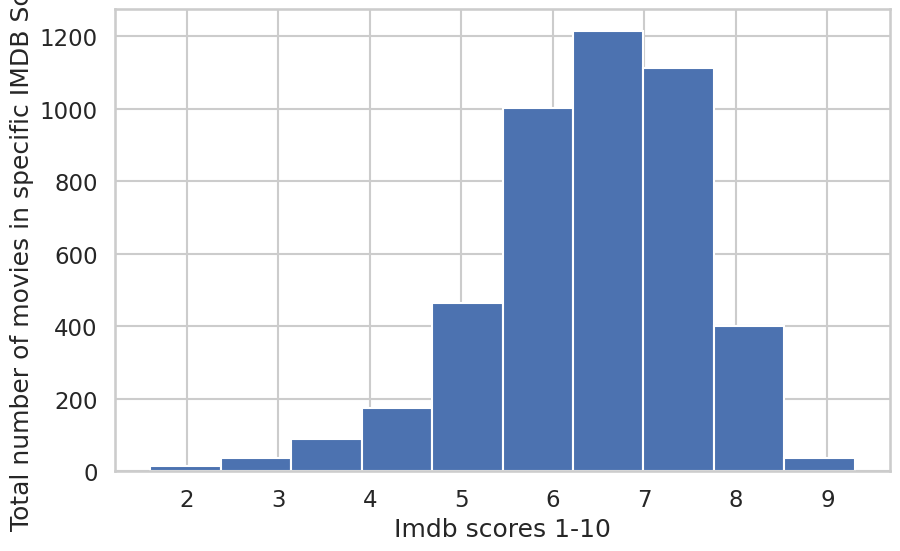

In [ ]:
plt.hist(df['imdb_score'])
plt.xlabel('Imdb scores 1-10')
plt.ylabel('Total number of movies in specific IMDB Score')

In [ ]:
df['movie_facebook_likes'].describe()

,movie_facebook_likes
count,4543.000000
mean,8069.130751
std,20083.380981
min,0.000000
25%,0.000000
50%,178.000000
75%,6500.000000
max,349000.000000


----------
### 1.2.5 Correlation Between Social Media Popularity and IMDb Scores
We use a scatter plot to examine the relationship between `cast_total_facebook_likes` and `imdb_score`. This visualization helps us identify if a star-studded cast (indicated by high Facebook likes) correlates with higher movie ratings, or if the data points are widely dispersed, suggesting a weaker relationship.

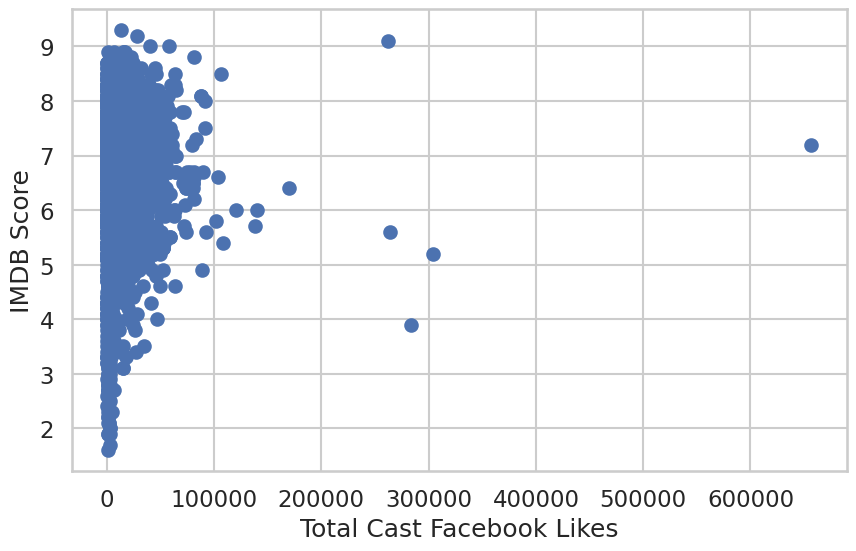

In [ ]:
plt.scatter(df['cast_total_facebook_likes'], df['imdb_score'])
plt.xlabel("Total Cast Facebook Likes")
plt.ylabel("IMDB Score")
plt.show()

--------------
### 1.2.6 Exploring the Impact of Budget on Ratings
This scatter plot visualizes the relationship between a movie's `budget` and its `imdb_score`. We are looking to see if higher financial investment typically results in better critical or audience reception, or if "blockbuster" budgets do not necessarily guarantee a high IMDb score.

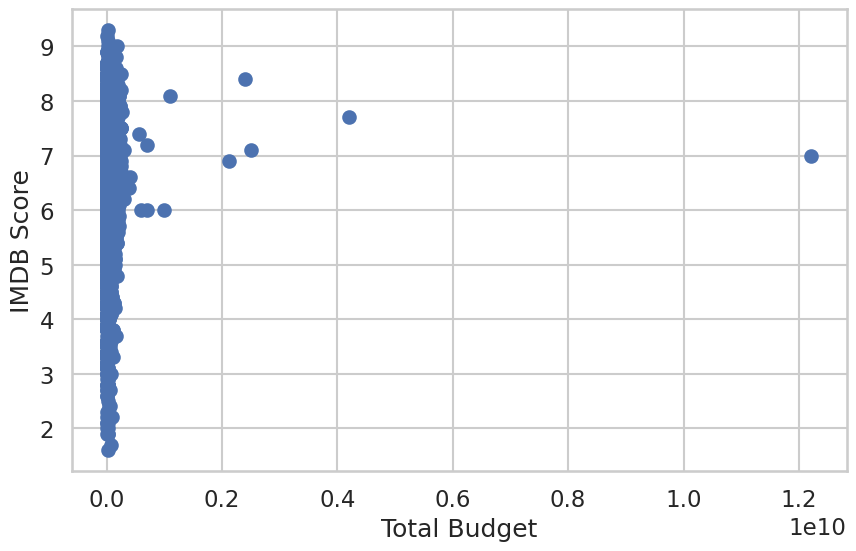

In [ ]:
plt.scatter(df['budget'], df['imdb_score'])
plt.xlabel("Total Budget")
plt.ylabel("IMDB Score")
plt.show()

--------------
### 1.2.7 Examining the Relationship Between Runtime and IMDb Scores
In this visualization, we plot `duration` against `imdb_score` to see if the length of a movie has any discernible impact on its rating. This helps us identify if longer movies tend to receive higher scores (perhaps due to being "epics") or if there is an optimal runtime range for highly-rated films.

Text(0, 0.5, 'IMDB Score')

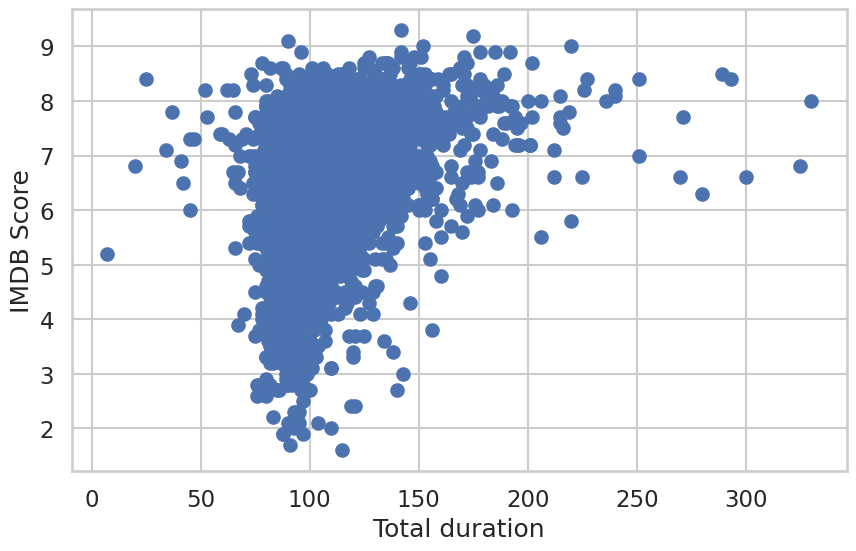

In [ ]:
plt.scatter(df['duration'], df['imdb_score'])
plt.xlabel("Total duration")
plt.ylabel("IMDB Score")

--------------
### 1.2.8 Historical Trends in IMDb Scores
By plotting `title_year` against `imdb_score`, we can observe how movie ratings have evolved over time. This scatter plot helps us identify if there are specific eras of cinema that consistently produced higher-rated films and whether the volume and variance of scores have changed as the industry grew.

Text(0, 0.5, 'IMDB Score')

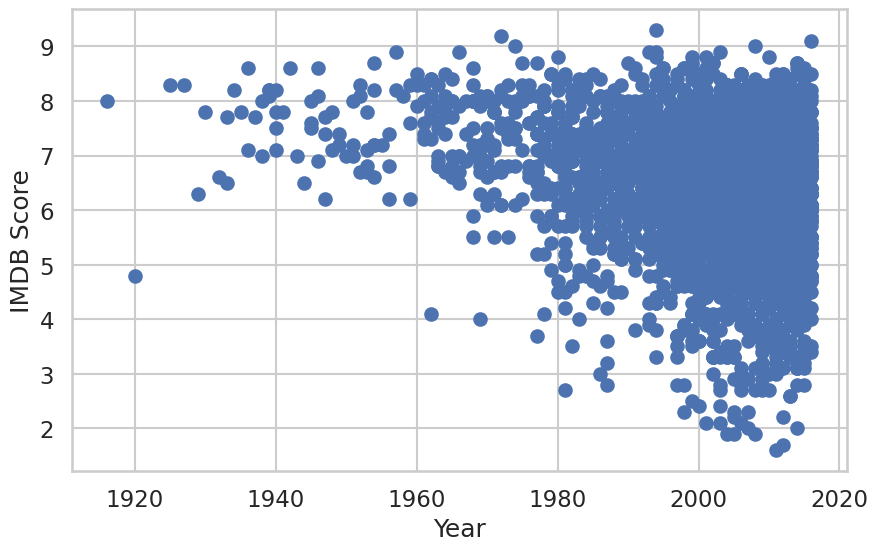

In [ ]:
plt.scatter(df['title_year'], df['imdb_score'])
plt.xlabel("Year")
plt.ylabel("IMDB Score")

--------------
### 1.2.9 Genre Distribution Analysis
We use `value_counts()` on the `genres` column to understand the diversity of the dataset. This helps us identify the most frequent movie categories and determines if the dataset is balanced across different genres or heavily skewed toward specific ones like Drama or Comedy.

In [ ]:
df['genres'].value_counts()

,count
genres,
Drama,193
Comedy,173
Comedy|Drama|Romance,165
Comedy|Drama,164
Comedy|Romance,148
...,...
Horror|Musical,1
Action|Romance|Sport,1
Biography|Documentary|Sport,1


--------------
### 1.2.10 Distribution of IMDb Scores Across Genres
We use a boxplot to compare the distribution of `imdb_score` across different `genres`. This allows us to see the median rating, the spread (interquartile range), and potential outliers for each category. It is a key step in identifying if certain genres consistently perform better than others before we proceed to formal ANOVA testing.

<Figure size 1200x600 with 0 Axes>

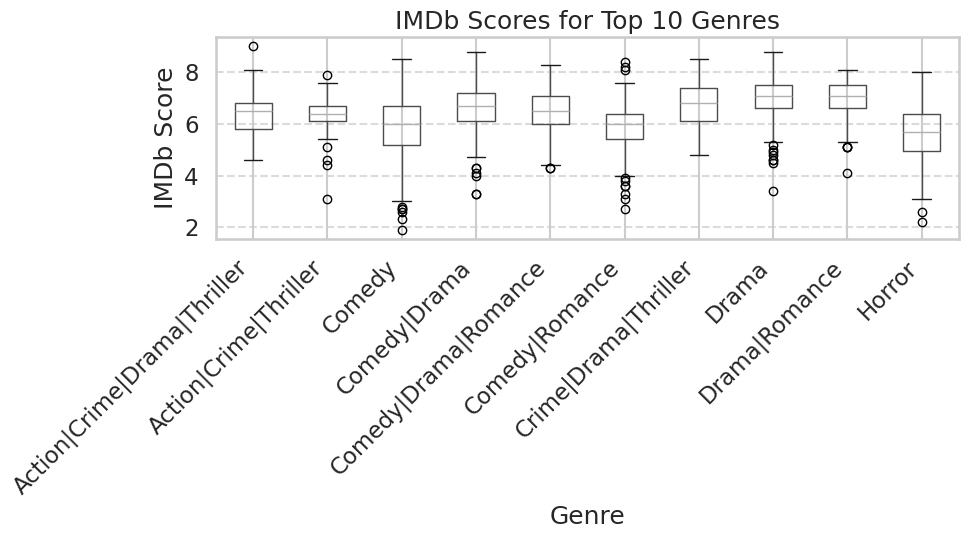

In [ ]:
# Filter to keep only the top 10 most frequent genres to reduce clutter
top_genres = df['genres'].value_counts().nlargest(10).index
df_filtered = df[df['genres'].isin(top_genres)]

# Create the cleaned boxplot
plt.figure(figsize=(12, 6))
df_filtered.boxplot(column='imdb_score', by='genres', rot=45)
plt.title('IMDb Scores for Top 10 Genres')
plt.suptitle('') # Remove the default automatic title
plt.xlabel('Genre')
plt.ylabel('IMDb Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task 2: Regression Analysis (PPT Slide 6-8)

1.   List item
2.   List item


## Research Question: To what extent is the movies IMDb score associated with popularity indicators and production characteristics?
Here Multiple Linear Regression is used to analyze the relation between movie glory and various parameters.

### 2.1 Model initialization & Data Preprocessing (PPT Slide 6-7)
For data analysis and model interpretability we have renamed some columns for understanding.

- Target Variable `Y` - `imdb_score`
- Predictor Variables `X`:
    - `fb_likes` : Social media visibility and liking
    - `budget` : Total money invested
    - `year` : Release Year
    - `runtime` : Duration of movie (mins)

We are using `statsmodels` model for fitting library, for internept in our linear equation we have added a constant.

In [ ]:
df = pd.read_csv("IMDBMovieScores.csv")

# Keep only needed columns and drop missing
df = df[['imdb_score','movie_facebook_likes','budget','duration','title_year']].dropna()

# Rename for clarity
df = df.rename(columns={'duration':'runtime', 'title_year':'year','movie_facebook_likes':'fb_likes'})

X = df[['fb_likes','budget','runtime','year']]
X = sm.add_constant(X)
y = df['imdb_score']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             imdb_score   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     297.7
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          1.25e-227
Time:                        23:46:22   Log-Likelihood:                -6400.1
No. Observations:                4538   AIC:                         1.281e+04
Df Residuals:                    4533   BIC:                         1.284e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.9461      2.500     18.778      0.0

### 2.2 Multivariate Exploration (Pairplot)

For visualising the pair wise relationship between all variables in a regression model we are using `pair plot`.
Factors which we can analyse from this are:
- Identity linear trends
- Checking distributions
- Detecting multicolinearity

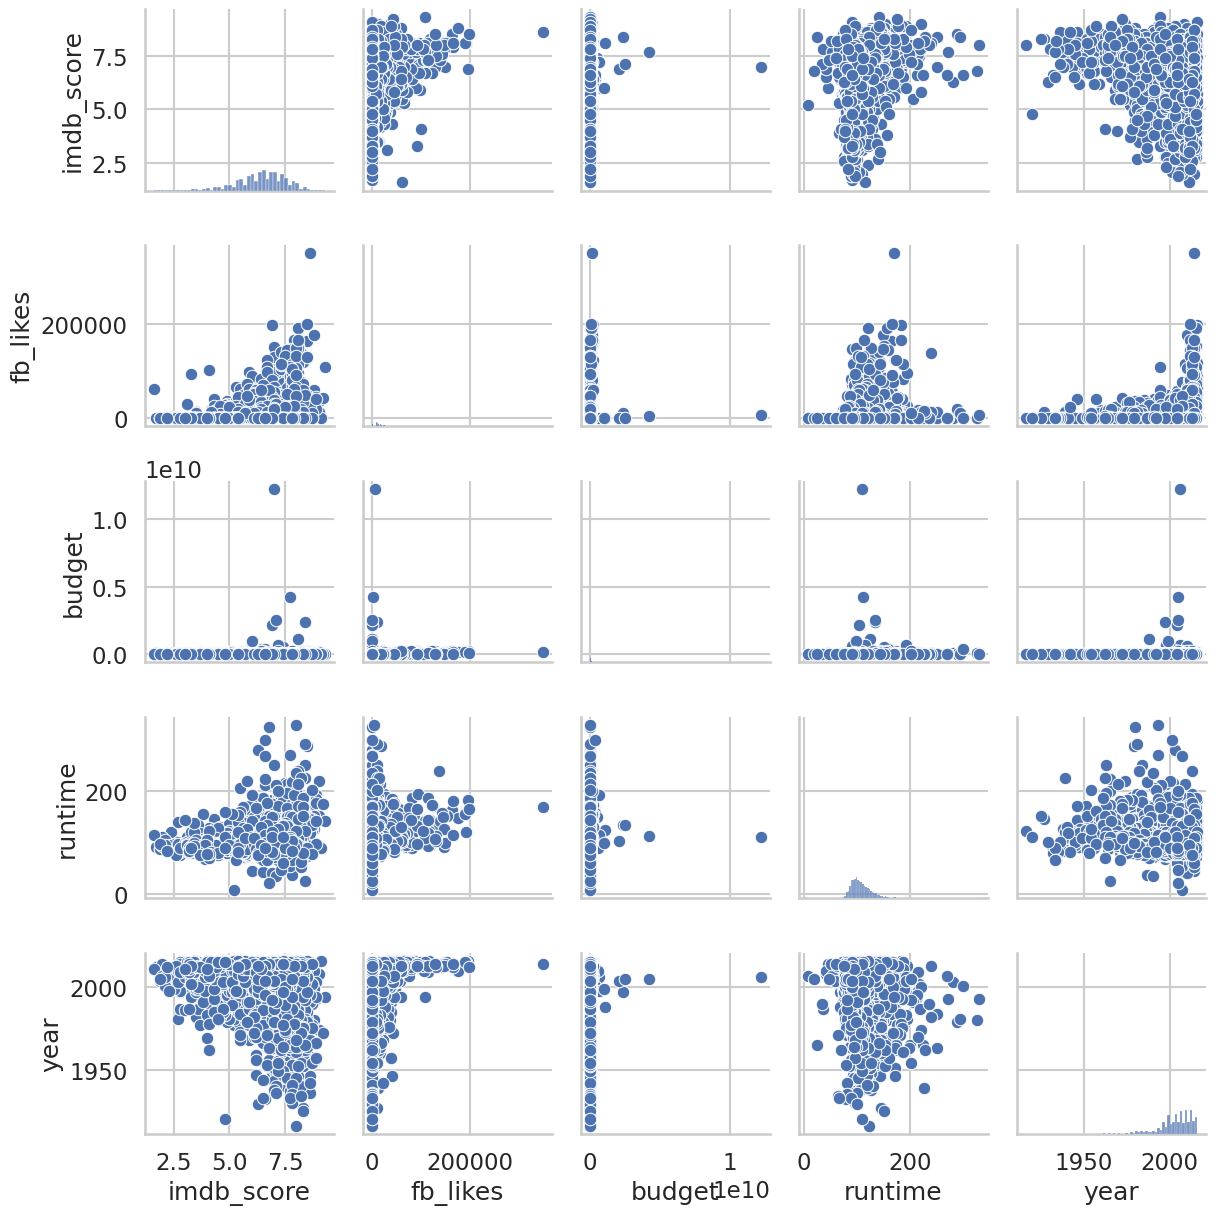

In [ ]:
sns.pairplot(df[['imdb_score','fb_likes','budget','runtime','year']])
plt.tight_layout()
plt.show()

-------------
### 2.3 Linear relationship visualisation: Facebook likes vs IMDB score (PPT Slide 7)
For generating scatter plot with a fitted regression line we are using `sns.regplot`. Here we can easily understand the direction and the strength Correlation between `fb_likes` and `imdb_likes`. The shaded area under the line depicts the confidence interval, allowing us to understand the reliability of the trend.

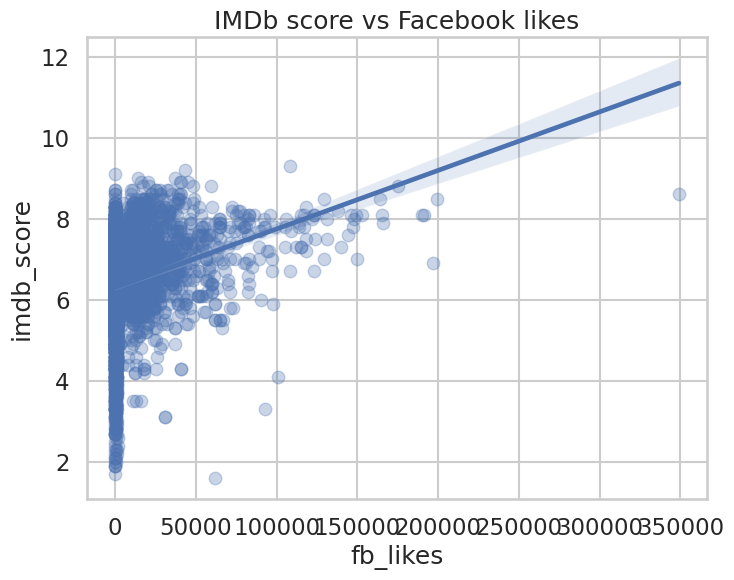

In [ ]:
# Plot 1: IMDb score vs Facebook likes
plt.figure(figsize=(8, 6))
sns.regplot(x='fb_likes', y='imdb_score', data=df, scatter_kws={'alpha':0.3})
plt.title("IMDb score vs Facebook likes")
plt.show()

---------
### 2.4 Trend analysis of investment: Budget vs Imdb score (PPT Slide 7)

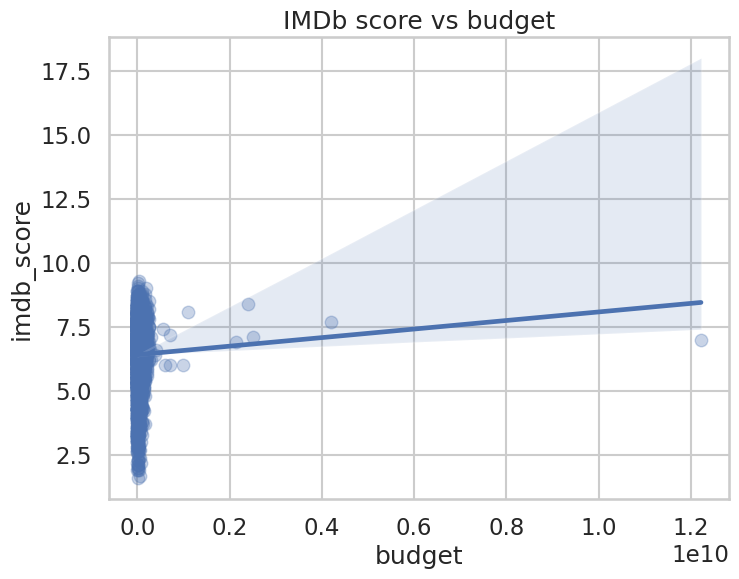

In [ ]:
# Plot 2: IMDb score vs budget
plt.figure(figsize=(8, 6))
sns.regplot(x='budget', y='imdb_score', data=df, scatter_kws={'alpha':0.3})
plt.title("IMDb score vs budget")
plt.show()

-----------
### 2.5 Analysis of Runtime vs IMDb score (PPT Slide 7)

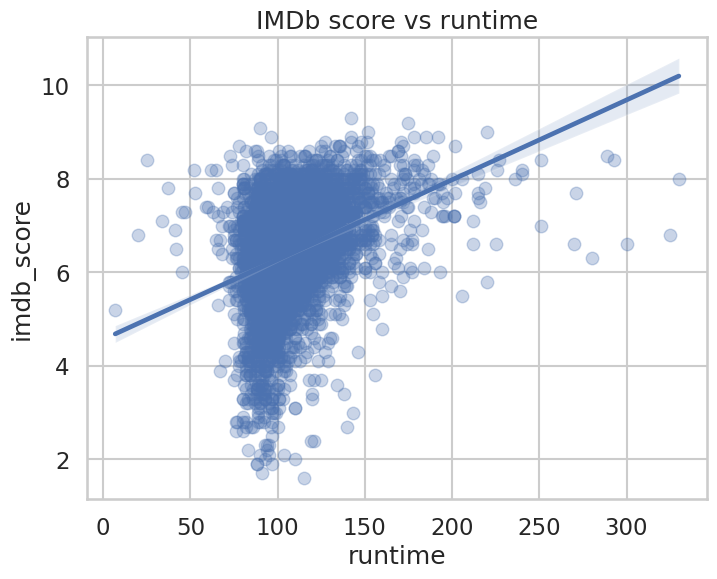

In [ ]:
# Plot 3: IMDb score vs runtime
plt.figure(figsize=(8, 6))
sns.regplot(x='runtime', y='imdb_score', data=df, scatter_kws={'alpha':0.3})
plt.title("IMDb score vs runtime")
plt.show()

-----------
### 2.6 Analysis of Release Year vs IMDb Score (PPT Slide 7)

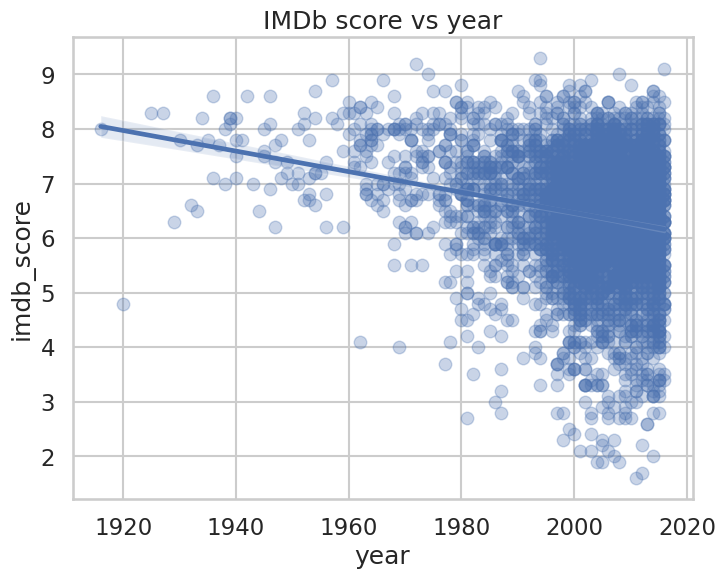

In [ ]:
# Plot 4: IMDb score vs year
plt.figure(figsize=(8, 6))
sns.regplot(x='year', y='imdb_score', data=df, scatter_kws={'alpha':0.3})
plt.title("IMDb score vs year")
plt.show()

-------------
### 2.7 Scaling feature for better interpretability of model
Here we are transforming the variables To more interpretable scale.

In [ ]:
df['fb_likes_k'] = df['fb_likes'] / 1000
X = df[['fb_likes_k','budget','runtime','year']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [ ]:
df['budget_m'] = df['budget'] / 1_000_000
X = df[['fb_likes_k','budget_m','runtime','year']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [ ]:
df['fitted'] = model.fittedvalues
df['residual'] = model.resid

rmse = np.sqrt(np.mean(df['residual']**2))
print("RMSE:", rmse)

RMSE: 0.991422507573798


---------
### 2.8 Performance analysis of model: Predicted vs Real IMDb score (PPT Slide 8)

- **Red Line:** Perfect prediction line
- **The scatter points:** Used for determining accuracy


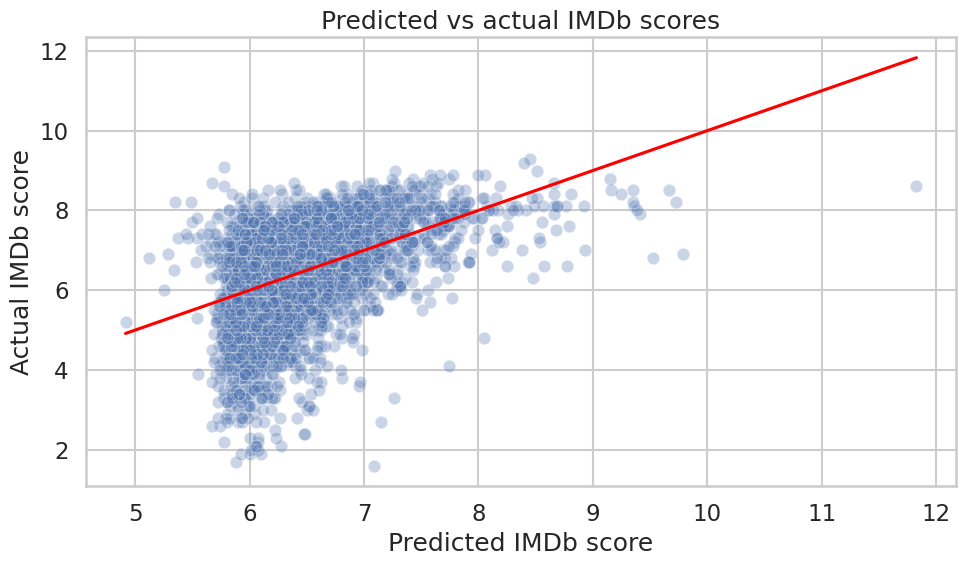

In [ ]:
sns.scatterplot(x=df['fitted'], y=df['imdb_score'], alpha=0.3)
plt.plot([df['fitted'].min(), df['fitted'].max()],
         [df['fitted'].min(), df['fitted'].max()],
         color='red')
plt.xlabel("Predicted IMDb score")
plt.ylabel("Actual IMDb score")
plt.title("Predicted vs actual IMDb scores")
plt.tight_layout()
plt.show()

----------
### 2.9 Assessment of Normality of residuals (PPT Slide 8)
If the residuals are normally distributed it is assumed to be multiple linear regression.
Methods to verify this:
1. **Normal Q-Q Plot:** Values of quantiles of a residual Are plotted against the contials of a theoretical normal distribution If it is observed that the residuals are normal The point should fall closely along the red diagonal line And if the line is deviated it is suggested For a deviation
2. **Shapiro-Wilk Test:** This test is considered as the statistical test for normality

   **Null Hypothesis($H_0$):** This means that the residuals are normal distributed

   **P-value interpretation:** The Null Hypothesis Mira rejected if the P value is higher than 0 .05 indicating that the normalcy assumption is upheld.

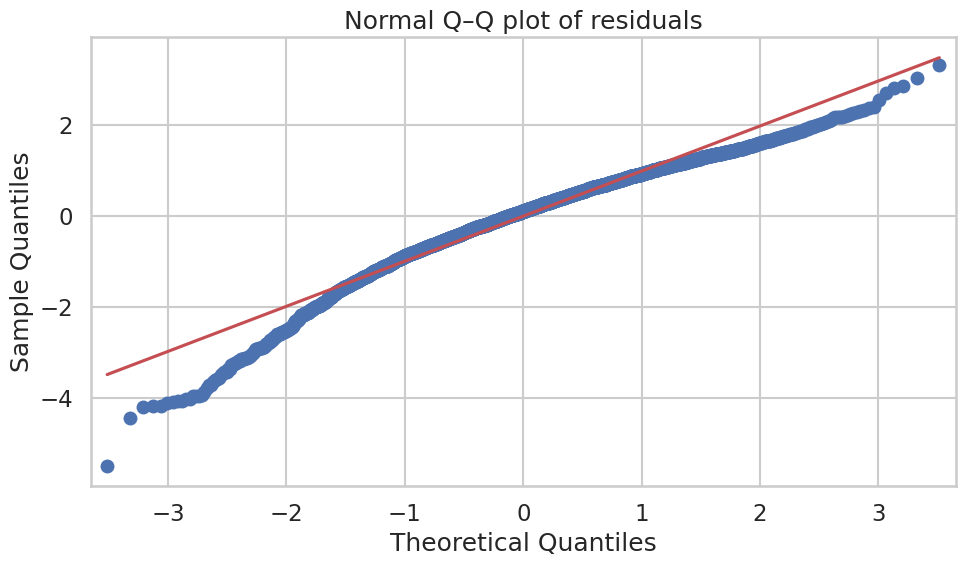

Shapiro-Wilk p-value: 1.2118929240146769e-09


In [ ]:
# Q-Q plot
sm.qqplot(df['residual'], line='s')
plt.title("Normal Q–Q plot of residuals")
plt.tight_layout()
plt.show()

# Shapiro-Wilk test (or another test)
stat, p = stats.shapiro(df['residual'].sample(500, random_state=0))  # sample if many rows
print("Shapiro-Wilk p-value:", p)

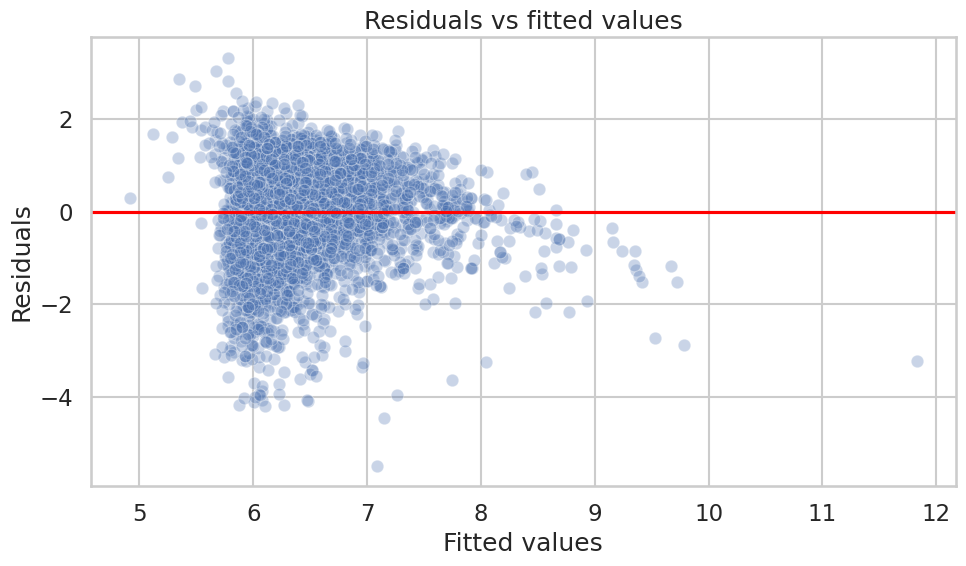

In [ ]:
sns.scatterplot(x=df['fitted'], y=df['residual'], alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(df['residual'], X)
print("Breusch–Pagan p-value:", bp_test[1])

Breusch–Pagan p-value: 5.835519665057383e-11


---------
### Varian Inflation Factor
Multicollinearity in a multipleregression is result of significant correlations between independent variables. The model coefficients may become uns....challenging to understand as a result

In [ ]:
# EXTENDED ANALYSIS: Checking for Multicollinearity using Variance Inflation Factor (VIF)
# This ensures our predictors aren't too highly correlated with each other.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the features used in the final model
features = df[['fb_likes_k','budget_m','runtime','year']]
X_vif = sm.add_constant(features)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("--- Multicollinearity Check (VIF) ---")
print(vif_data)
print("\nInterpretation: VIF scores below 5 indicate no problematic multicollinearity.")

--- Multicollinearity Check (VIF) ---
      Feature           VIF
0       const  28824.538988
1  fb_likes_k      1.136955
2    budget_m      1.009913
3     runtime      1.101052
4        year      1.106104

Interpretation: VIF scores below 5 indicate no problematic multicollinearity.


----------
## 2.10 Conclusion

Although popularity metrics like Facebook likes and production attributes like runtime have a statistically significant Correlation with IMDb scores, our study shows that they only account for a part of the variation ($R^2$). This suggests that even while bigger and more popular tends to be associated with better ratings A film's quality is still a complicated factor that goes beyond straight forward financial or social media.


# TASK 3: Analysis of Variance (ANOVA) (PPT Slide 9-11)
## Research Question: Do average IMDb scores differ significantly across movie genres?

  We can do this by running a one-way ANOVA to test if the genre of a movie affects the IMDb rating. For this section we only consider the primary genre, instead of considering all the multiple genres for better results.

### Hypotheses:
* **Null Hypothesis ($H_0$):** The mean IMDb scores for various movie genres do not significantly differ from one another.
* **Alternative Hypothesis ($H_a$):** The IMDb score for at least one genre of film differs significantly from the others.

### 3.1 Data Refinement and Genre Categorization  (PPT Slide 9)
We need to prepare the `genres` data before performing the ANOVA. For example, "Action|Adventure|Sci-Fi" is a list of movies that fall under more than one genre. For the test, we simplify the classification so that every video is in a single unique category.



In [ ]:
# Reload the dataset to get the 'genres' column back
df = pd.read_csv("IMDBMovieScores.csv")

# Re-apply the basic cleaning from Task 1 so you aren't working with bad data
df = df.dropna(subset=['budget', 'title_year'])
df['duration'] = df['duration'].fillna(df['duration'].median())

##Considering only the first genres.
df["primary_genre_category"]=df["genres"].str.split("|").str[0]

In [ ]:
## The primary_genre_category genre category is counted according to its accourence.
genre_app=df["primary_genre_category"].value_counts()
print(genre_app)

primary_genre_category
Comedy         1169
Action         1098
Drama           840
Adventure       433
Crime           298
Biography       233
Horror          215
Documentary      67
Animation        51
Fantasy          47
Mystery          32
Thriller         16
Sci-Fi           13
Family           11
Western          11
Romance           6
Musical           2
Film-Noir         1
Name: count, dtype: int64


In [ ]:
##Removing the rows with genre count less than 30.
valid_genre=genre_app[genre_app>=30].index
df=df[df["primary_genre_category"].isin(valid_genre)]

In [ ]:
#Which genre has higher and lower mean, median, std.
genre_distribution =df.groupby("primary_genre_category")["imdb_score"].agg(["count", "mean", "median", "std"])
print(genre_distribution)

                        count      mean  median       std
primary_genre_category                                   
Action                   1098  6.228506     6.3  1.096060
Adventure                 433  6.514319     6.7  1.121828
Animation                  51  6.649020     6.9  1.126121
Biography                 233  7.155365     7.2  0.708129
Comedy                   1169  6.156116     6.3  1.075203
Crime                     298  6.859396     6.9  0.953142
Documentary                67  7.100000     7.4  1.256981
Drama                     840  6.784524     6.9  0.976053
Fantasy                    47  6.397872     6.5  0.895275
Horror                    215  5.700930     5.7  1.137344
Mystery                    32  6.540625     6.7  1.148592


### 3.2 Visualizing IMDB score by genre with box plot

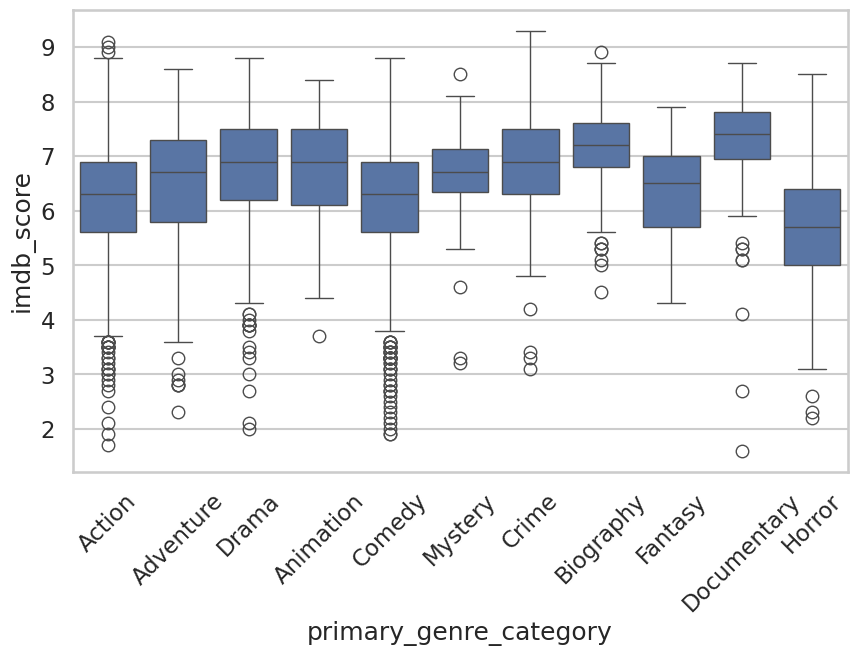

In [ ]:
##Boxplot of IMDB score by genre
sns.boxplot(x="primary_genre_category", y="imdb_score", data=df)
plt.xticks(rotation=45)
plt.show()

Observation:

The categories with the highest median IMDb scores are crime, biography, and documentary.

### 3.3 Violin Plot Analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Action'),
  Text(1, 0, 'Adventure'),
  Text(2, 0, 'Drama'),
  Text(3, 0, 'Animation'),
  Text(4, 0, 'Comedy'),
  Text(5, 0, 'Mystery'),
  Text(6, 0, 'Crime'),
  Text(7, 0, 'Biography'),
  Text(8, 0, 'Fantasy'),
  Text(9, 0, 'Documentary'),
  Text(10, 0, 'Horror')])

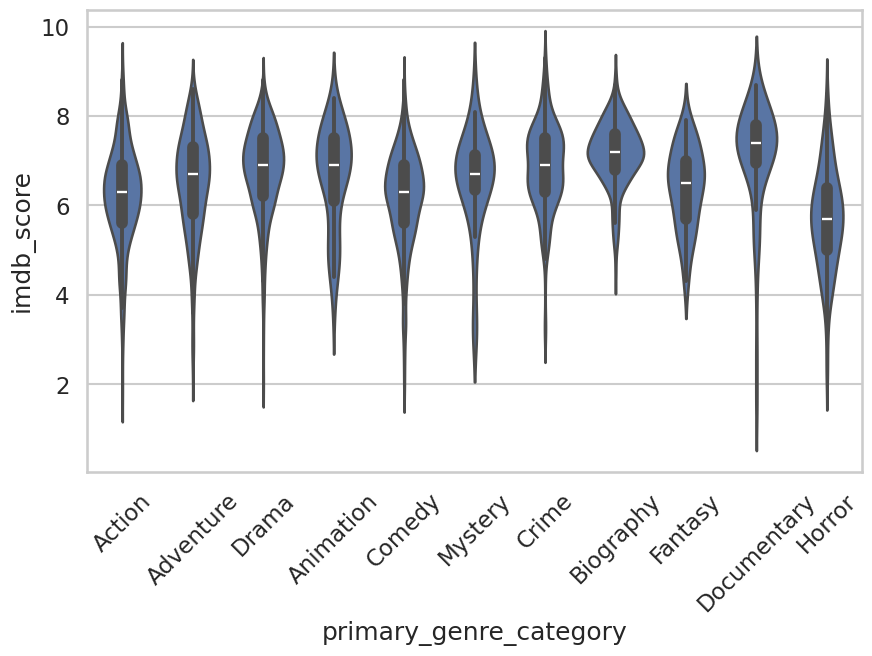

In [ ]:
##Violin Plot
sns.violinplot(x="primary_genre_category", y="imdb_score", data=df)
plt.xticks(rotation=45)

Observation:
Most films in the documentary, biography and crime genres have relatively high ratings, with a greater density in the 7-8 IMDb score range.

-----------

### 3.4 Sample Size Distribution: Movies per Genre
The occurrence of films within each genre group is shown in this bar chart.

Text(0, 0.5, 'Count')

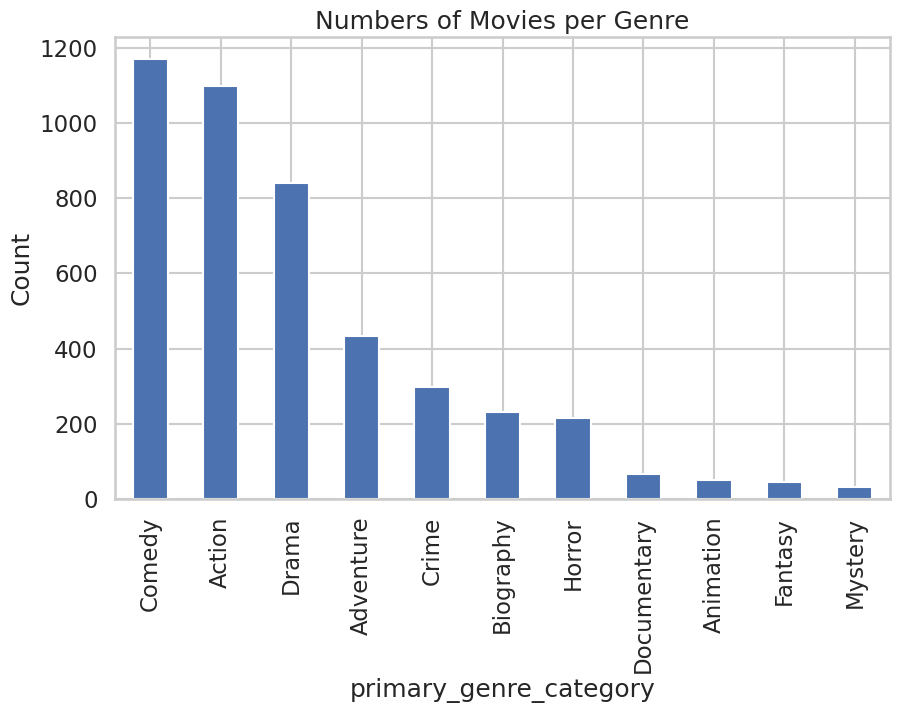

In [ ]:
## Bar chart of moies per genre
df["primary_genre_category"].value_counts().plot(kind="bar")
plt.title("Numbers of Movies per Genre")
plt.ylabel("Count")

### 3.5 Statistical Analysis: Fitting the ANOVA Model (PPT Slide 12-14)
Analysis of Variance, or ANOVA, is a statistical procedure for comparing the means of three or more groups. In this research, it is used to examine whether the average IMDb ratings are unequal across genres. Rather than examining each genre separately, ANOVA examines all groups simultaneously and returns a result indicating whether at least one group has a significantly different average value.

**ANOVA Results:** (PPT Slide 13)
* We conducted an ANOVA test to see whether the IMDb ratings are significantly different across the genres.
* F(10, 4472) = 51.42
* p = 2.42 × 10⁻⁹⁸ (< 0.001)

Since p < 0.001, we reject the null hypothesis.

The IMDb ratings are significantly different across genres.

In [ ]:
model = smf.ols('imdb_score ~ C(primary_genre_category)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(primary_genre_category),565.690188,10.0,51.422667,2.419412e-98
Residual,4919.555277,4472.0,NaN,NaN


In [ ]:
residuals = model.resid
fitted = model.fittedvalues
residuals.head()

,0
0,1.671494
1,0.871494
2,0.571494
3,2.271494
5,0.371494


---
### 3.6 Assumption Check: Normality of Residuals (PPT Slide 13)
The Q-Q plot is employed to verify the assumption of normality of residuals in ANOVA. In our situation, most data points lie on the line, but there are some discrepancies in the tails.

* The Q-Q plot verifies if the residuals are normally distributed.
* If the points lie on the straight line, then normality is met.
* In our graph, the points slightly stray from the line, particularly in the tails.
* This is an indication of some departure from normality, but the trend is almost linear.

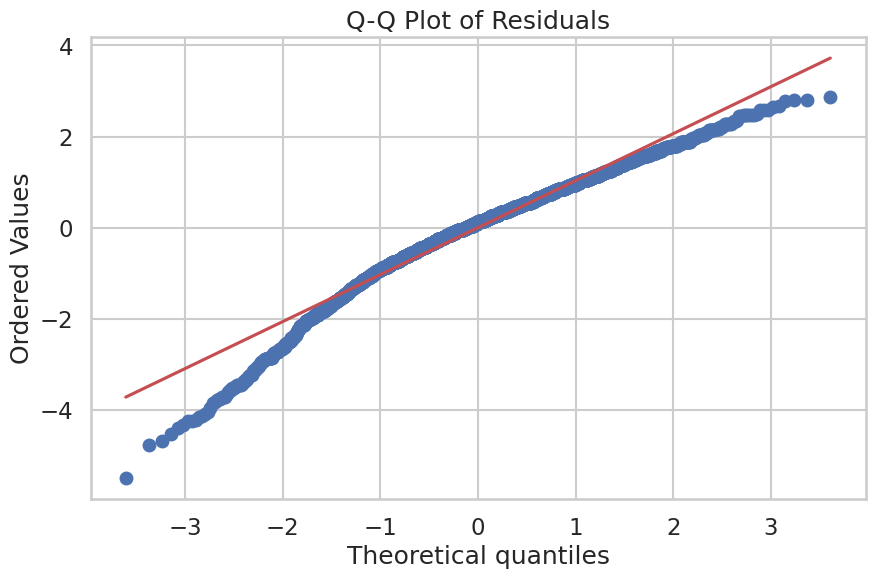

In [ ]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

The Q-Q plot enables us to make a final assessment regarding the correctness of our ANOVA model:

* **Adherence to the Trend:** If most of the data points are on or very close to the red line, then we can state that our residuals are normally distributed, which is a fundamental requirement of the ANOVA test.

* **Tails and Outliers:** Data points that tend to stray away from the red line at the very top or very bottom correspond to movies with "extreme" ratings that are not entirely captured by the genre average. However, in a large data set such as this one, small anomalies in the tails are not uncommon and do not affect the outcome of the F-test.

**Conclusion:** Based on the alignment, our model is valid for making inferences regarding the differences between genre averages.

--------------
### 3.7 Validating Assumptions and Non-Parametric Testing
To ensure the integrity of our findings, we perform a final round of rigorous statistical checks:

1. **Homogeneity of Variance (Levene’s Test)**
    * Levene’s test checks whether group variances are equal.
    * Statistic = 5.45
    * p < 0.001

    Since p < 0.05, the equal variance assumption is violated.

2. **ANOVA Result**
    * F(10, 4472) = 51.42
    * p < 0.001
    * We reject the null hypothesis.

    There is a significant difference in mean IMDb scores across genres.

2. **Kruskal–Wallis Test (Non-parametric Alternative)** (PPT Slide 14)
    * H = 541.67
    * p < 0.001
    * This test also shows a significant difference between genres.

    So, even without assuming normality and equal variances, the result remains significant.


IMDb scores differ significantly across primary genres, and this finding is supported by both ANOVA and Kruskal–Wallis tests.








In [ ]:
groups = [group["imdb_score"].values for name, group in df.groupby("primary_genre_category")]
levene_test = levene(*groups)
levene_test

LeveneResult(statistic=np.float64(5.452069379747027), pvalue=np.float64(4.37857728861587e-08))

In [ ]:
# Use .iloc[0] to explicitly get the first value by position
F = anova_table["F"].iloc[0]
p = anova_table["PR(>F)"].iloc[0]

print(f"F-statistic: {F}")
print(f"p-value: {p}")

F-statistic: 51.42266684995563
p-value: 2.4194117769541187e-98


In [ ]:
kruskal_test = kruskal(*groups)
kruskal_test

KruskalResult(statistic=np.float64(541.6729544634089), pvalue=np.float64(5.423349185623182e-110))

The findings from our analyses directly address the research question about the relationship between genre and IMDb ratings.

* **Levene’s Test ($p < 0.001$):** The very small p-value suggests that the variances are not equal for different genres. Some genres have more variation in their IMDb ratings than others.
* **ANOVA Results ($F \approx 51.42, p \approx 0$):** ANOVA Results (F≈51.42,p≈0): The large F-statistic and the very small p-value suggest that the differences in mean IMDb ratings for different genres are statistically significant and not due to random sampling error.
* **Kruskal-Wallis Test ($p \approx 0$):** Kruskal-Wallis Test (p≈0): Since the equal variance assumption was not met, we used this non-parametric test as a robustness check. This test also yielded a highly significant result, consistent with the ANOVA result.

There is strong statistical evidence that movie genre is a significant predictor of IMDb ratings.

---------
### 3.8 Post-Hoc Analysis: Tukey’s Honestly Significant Difference (HSD) (PPT Slide 15-17)
The ANOVA result confirmed that *at least one* genre is different from the others, but it does not tell us which specific pairs are different. To find those specific differences, we perform a **Tukey HSD Test**.

**Why this test is necessary:** (PPT Slide 15)
* **Pairwise Comparisons:** It compares every genre against every other genre (e.g., Action vs. Drama, Comedy vs. Horror).
* **Error Control:** When performing many comparisons, the risk of a "false positive" (Type I error) increases. Tukey’s HSD adjusts for this, ensuring our conclusions remain statistically sound.
* **Significant Pairs:** In the output table, any row where `reject = True` indicates a statistically significant difference in the average IMDb scores between those two specific genres.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(
    endog=df['imdb_score'],
    groups=df['primary_genre_category'],
    alpha=0.05
)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
     Action   Adventure   0.2858 0.0001  0.0941  0.4775   True
     Action   Animation   0.4205 0.1586 -0.0633  0.9043  False
     Action   Biography   0.9269    0.0  0.6832  1.1705   True
     Action      Comedy  -0.0724 0.8641 -0.2143  0.0696  False
     Action       Crime   0.6309    0.0  0.4103  0.8515   True
     Action Documentary   0.8715    0.0  0.4464  1.2965   True
     Action       Drama    0.556    0.0  0.4012  0.7108   True
     Action     Fantasy   0.1694  0.992 -0.3337  0.6725  False
     Action      Horror  -0.5276    0.0 -0.7795 -0.2757   True
     Action     Mystery   0.3121 0.8561 -0.2936  0.9178  False
  Adventure   Animation   0.1347 0.9987 -0.3653  0.6347  False
  Adventure   Biography    0.641    0.0  0.3666  0.9155   True
  Adventure      Comedy  -0.3582    0.0 -0.5482 -0.1682

###Results and Interpretation - The Tukey HSD results reveal clear and systematic differences in average IMDb scores across movie genres.Genres such as Biography, Documentary,Drama and crime consistently show significantly higher mean IMDb ratings when compared with more mainstream genres such as action and comedy. For example, Biography films score, on average, nearly one IMDb point higher than action and comedy films, and these differences are statistically significant(p < 0.05).

###In contrast horror films consistently receive significantly lower IMDb ratings than most other genres, including action, adventure, drama, crime,Documentary and Fantasy. This indicates that horror is the lowest-rated genre on average in the dataset.Several genre pairs show no statistically significant difference , such as action vs Comedy , Drama vs Mystery, and Fantasy vs Mystery, suggesting that movies within these genre pairs tend to receive similar IMDb ratings.Overall, the Tukey HSD analysis confirms that IMDb ratings are not evenly distributed across genres. Narrative driven and factual genres (such as Biography and Documentary)tend to be rated more favourably by audiences while horror films tend to receive lower ratings. These differences are both statistically significant and practically significant.
---
### 3.9 Visualizing Mean Differences: Point Plot with 95% Confidence Intervals (PPT Slide 16)
To synthesize our statistical findings, we use a **Point Plot**. This visualization is the most direct way to see the "rank" of each genre and the reliability of their average scores.

* **Mean Points:** The dots represent the average IMDb score for each genre. We can clearly see which genres (e.g., Biography or Drama) sit at the top of the scale compared to others.
* **95% Confidence Intervals (CI):** The vertical lines represent the range in which we are 95% confident the true population mean lies.
* **Statistical Significance (Visual Check):** * If the error bars of two genres **do not overlap**, it strongly suggests that the difference between them is statistically significant (matching our Tukey HSD results).
* Wider bars indicate more variability or a smaller sample size within that genre, while tighter bars indicate a very consistent rating trend.

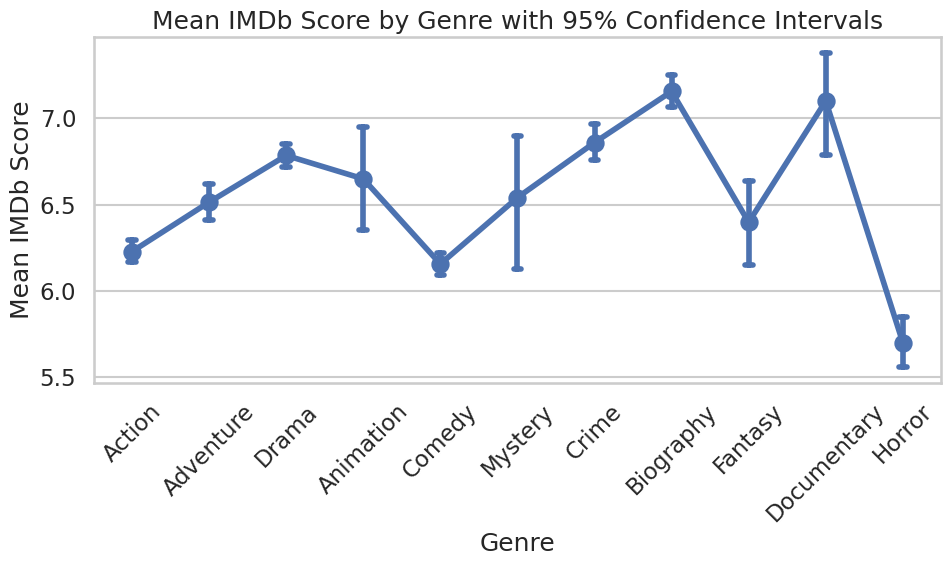

In [ ]:
plt.figure(figsize=(10,6))

sns.pointplot(
    data=df,
    x='primary_genre_category',
    y='imdb_score',
    errorbar=('ci', 95),  # UPDATED LINE
    capsize=0.1
)

plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Mean IMDb Score")
plt.title("Mean IMDb Score by Genre with 95% Confidence Intervals")
plt.tight_layout()
plt.show()

The point plot serves as the visual confirmation of our Tukey HSD results, allowing us to see exactly where the significant differences lie:

* **Top Performers:** Genres such as **Biography** and **Drama** clearly sit at the higher end of the IMDb scale. Since their confidence intervals (CIs) are relatively tight and do not overlap with several other genres, we can conclude they are significantly more likely to receive higher scores.
* **Consistency vs. Volatility:** A shorter error bar (like those often seen in **Comedy** or **Action**) suggests that the average score is very stable across a large number of movies. A larger error bar suggests that while the mean is at a certain level, there is more uncertainty or variety in how those movies are rated.
* **Visual Significance:** Any two genres whose vertical lines do not overlap are statistically different at the 95% confidence level. For instance, if the bar for **Drama** is entirely above the bar for **Horror**, the "Drama" genre effectively guarantees a higher average critical reception.

**Conclusion from Graph:** This plot demonstrates that genre is not just a label but a strong indicator of a movie's likely IMDb score, validating our decision to reject the Null Hypothesis.

--------------------

## 3.10 Conclusion for Task 3: The Impact of Genre on IMDb Scores (PPT Slide 17)

Based on our Analysis of Variance and subsequent diagnostic tests, we have reached the following conclusions regarding the relationship between movie genres and their IMDb ratings:

### 1. Rejection of the Null Hypothesis
The **ANOVA F-test** yielded a highly significant p-value ($p < 0.001$), providing strong statistical evidence to reject the Null Hypothesis ($H_0$). We conclude that a movie's genre does indeed play a statistically significant role in determining its average IMDb score.

### 2. Robustness of Findings
* Because our **Levene’s Test** indicated unequal variances, we validated our findings using the **Kruskal-Wallis** non-parametric test.
* The fact that both tests produced near-zero p-values confirms that the differences in genre means are genuine and not an artifact of data distribution or outliers.

### 3. Key Genre Insights
Through **Tukey’s HSD Post-Hoc analysis** and our **Point Plots**, we identified specific trends:
* **High-Ranking Genres:** Genres like **Biography** and **Drama** consistently achieve higher mean scores. These genres likely benefit from more "prestige" narratives or target audiences that are more inclined to give favorable ratings.
* **Lower-Ranking Genres:** Genres like **Horror** and **Comedy** tend to have lower average scores. These categories often see a high volume of releases with high variability, leading to a more diverse (and sometimes lower) critical reception.

**Final Answer:** The analysis confirms that the "Genre" category is a powerful predictor of critical success. While budget and social media popularity (Task 2) provide some predictive power, the genre itself sets a significantly different "baseline" for expected IMDb scores.

--------------------------
---

# TASK 4: Group Comparison Analysis (PPT Slide 18-21)
## Research Question: Is there a significant difference in IMDb scores between movies with high and low social media popularity?

Here, we use a Group Comparison Analysis to investigate the possibility of the existence of a significant difference in the IMDb scores between high and low social media popularity movies. Popularity is measured by movie Facebook likes and the films are split into two groups by a median split. To compare the average IMDb score of these groups, we use an Independent Samples t-test (Welch correction). A non-parametric (Mann–Whitney U test) is also performed and Cohen d is derived to assess the practical size of any observed difference.

**Why this is useful:**
* **Comparing Group Differences:** It will enable us to learn whether the highly popular films are rated significantly higher than the less popular films.
* **Evaluating Practical Impact:** When we compute effect sizes, we can then be more precise in identifying whether any identified difference has any practical significance or not.

In [ ]:
df = pd.read_csv("IMDBMovieScores.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

This dataset was initially cleaned by keeping all those variables that could answer the research question, such as IMDb score, movie Facebook likes, budget, and release year. The statistical analysis was done using observable data. Any data with missing values for the key variables were excluded to ensure the analysis was valid and reliable.

In [ ]:
df = df.dropna(subset=['imdb_score', 'movie_facebook_likes'])
df.shape

(5043, 28)

---
### 4.1 Median Split (Define Popularity Groups)

The movie Facebook likes variable was also split at the median in order to categorize films as either being highly popular or low in popularity. This was a strategy that balanced the group sizes and alleviated the impact of extreme skewness that is prevalent in social media measures.

In [ ]:
median_likes = df['movie_facebook_likes'].median()

df['popularity_group'] = np.where(
    df['movie_facebook_likes'] > median_likes,
    'High Popularity',
    'Low Popularity'
)

high_scores = df[df['popularity_group'] == 'High Popularity']['imdb_score']
low_scores = df[df['popularity_group'] == 'Low Popularity']['imdb_score']

print("Median Likes:", median_likes)
df['popularity_group'].value_counts()

Median Likes: 166.0


,count
popularity_group,
Low Popularity,2525
High Popularity,2518


---
### Visualizing Score Distributions: Overlapping Histograms (PPT Slide 18)
The visual analysis of the distribution of IMDb scores among high-popularity and low-popularity groups was conducted using an overlapping histogram before formal statistical tests were performed.

This visualization helps to:

* Determine whether or not the distributions are normally distributed.
* Compare the central tendency of scores on the IMDb between groups.
* Note the extent of overlap, which would imply similarity in ratings on levels of popularity.

The high overlap implies that there was a narrow difference between the two groups before formal hypothesis testing.

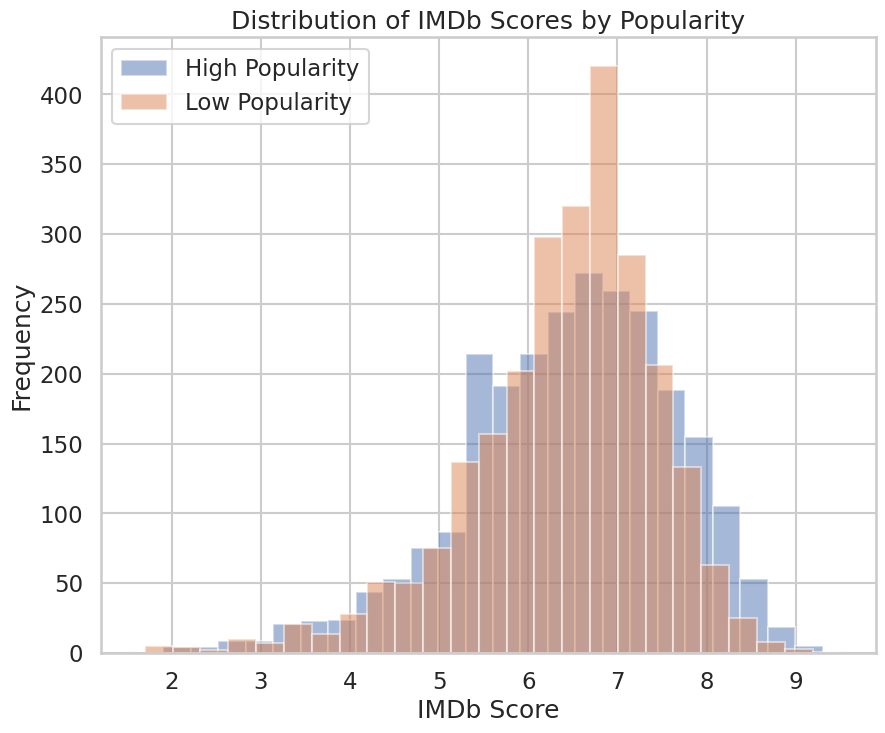

In [ ]:
plt.figure(figsize=(10,8))

plt.hist(high_scores, bins=25, alpha=0.5, label='High Popularity')
plt.hist(low_scores, bins=25, alpha=0.5, label='Low Popularity')

plt.xlabel("IMDb Score")
plt.ylabel("Frequency")
plt.title("Distribution of IMDb Scores by Popularity")

plt.legend()
plt.show()

---
### 4.2 Descriptive Statistics

Descriptive statistics showed that popular films by far had a slightly higher average IMDb rating than low-popularity films. Nevertheless, the disparity between group means was not substantial, and it can be supposed that popularity alone might not be very strong in affecting audience ratings.

In [ ]:
group_stats = df.groupby('popularity_group')['imdb_score'].agg(['mean', 'median', 'std', 'count'])
group_stats

,mean,median,std,count
popularity_group,,,,
High Popularity,6.469341,6.6,1.190285,2518
Low Popularity,6.415010,6.5,1.055669,2525


---
### 4.3 Histogram (Check Distribution)
The majority of movies belong to the 6-7 rating range, which indicates that average-rated movies represent the majority of the dataset.

IMDb Scores can be categorized into Discrete Ranges.
To obtain a better understanding of our movie ratings distribution, we can transform the continuous score of imdb to several distinct groups (bins).

**Why this is useful:**
Rather than viewing a continuous distribution of numbers, this frequency table will allow us to immediately notice where the great majority of movies lie. It usually indicates that the extreme scores (both very low and exceptionally high) tend to occur rarely, whereas the middle range (between 6-7) of the dataset occupies the majority.

In [ ]:
bins = [0,5,6,7,8,9,10]
labels = ['<5','5-6','6-7','7-8','8-9','9+']

df['score_range'] = pd.cut(df['imdb_score'], bins=bins, labels=labels)

range_frequency = df['score_range'].value_counts().sort_index()

range_frequency

,count
score_range,
<5,524
5-6,1061
6-7,1864
7-8,1341
8-9,247
9+,6


---
### Visualizing the Distribution of Binned IMDb Scores (PPT Slide 19)
This bar chart gives a visualization of the frequency table that we have just created in a clear and categorical way.

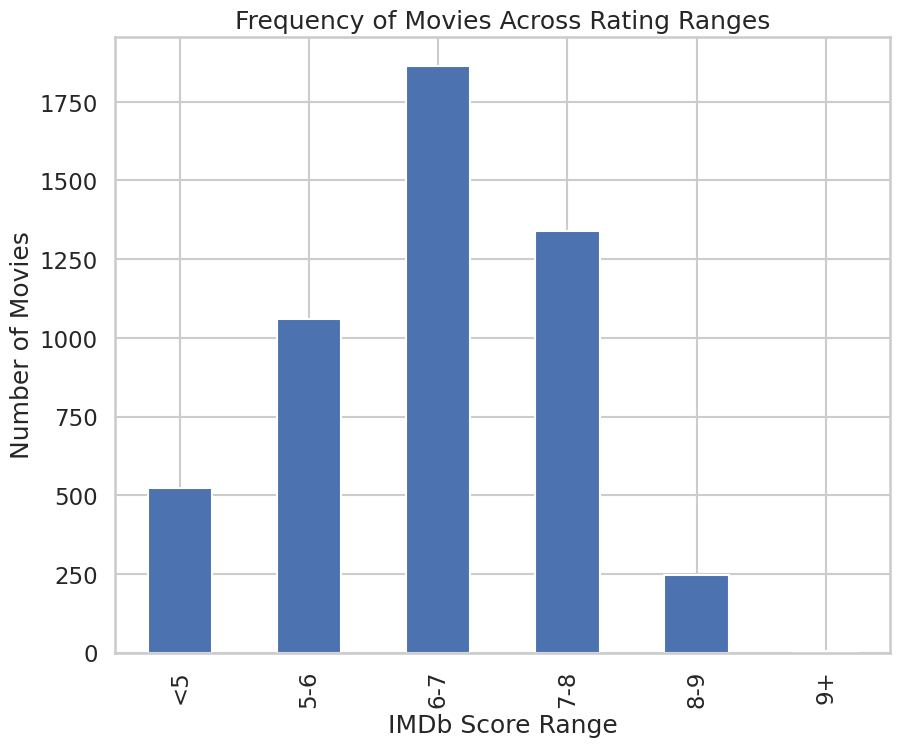

In [ ]:
range_frequency.sort_index().plot(kind='bar', figsize=(10,8))

plt.xlabel("IMDb Score Range")
plt.ylabel("Number of Movies")
plt.title("Frequency of Movies Across Rating Ranges")

plt.show()

---
### 4.4 Interpretation of Rating Frequencies
When we conduct our hypothesis tests with grouping (such as high vs. low popularity), we should remember that the expected score of a movie in the baseline is already closely concentrated with a score of 6.5 already.

-----------------------

### Shapiro–Wilk Test
The Shapiro-Wilk test showed that there were deviations towards normality, but since the sample size was large, such deviations were anticipated. Thus, the Mann-Whitney U test was performed as a robust alternative.

We test the Shapiro-Wilk where:
* Null Hypothesis (H 0 ) The data is normally distributed.
* Alternate Hypothesis (H a): The data are not normally distributed.

How to interpret the output:
When the p-value exceeds 0.05 then we do not reject the null hypothesis and the data is assumed to be normal. Here, we would go ahead with a parametric test, i.e., the **Independent Two-Sample T-Test.
* When the p-value has a value that is less than 0.05 then we reject the null hypothesis and say that data is not normally distributed. In this scenario, a nonparametric alternative, which is, the Mann-Whitney U Test, needs to be utilized.

In [ ]:
# Normality test for both groups
shapiro_high = stats.shapiro(high_scores)
shapiro_low = stats.shapiro(low_scores)

print("High Popularity Group:")
print("Statistic =", shapiro_high.statistic)
print("p-value =", shapiro_high.pvalue)

print("\nLow Popularity Group:")
print("Statistic =", shapiro_low.statistic)
print("p-value =", shapiro_low.pvalue)

High Popularity Group:
Statistic = 0.9753520311821084
p-value = 1.8975963655367187e-20

Low Popularity Group:
Statistic = 0.9591035942683291
p-value = 4.322628124981742e-26


---------------

### 4.6 Visualizing Score Distributions: Boxplot Comparison (PPT Slide 21)
Visualisation of the boxplot showed that there was significant overlap between the two categories of popular movies, meaning that although films with high popularity can slightly score higher ratings, the audience ratings in both sets are quite similar.

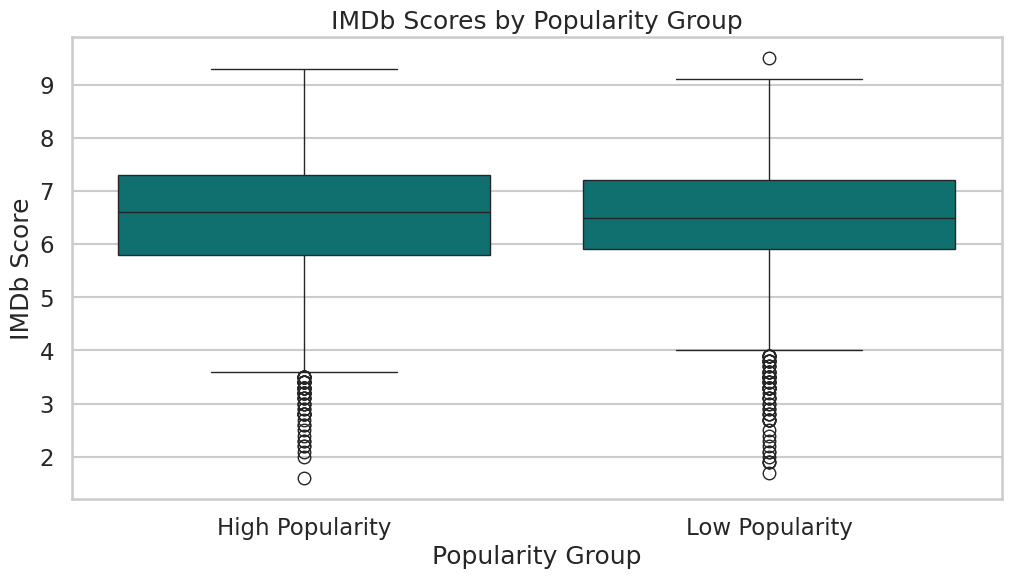

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='popularity_group',
    y='imdb_score',
    data=df,
    color='teal'
)

plt.title("IMDb Scores by Popularity Group")
plt.xlabel("Popularity Group")
plt.ylabel("IMDb Score")

plt.show()

### 4.7 Welch t-test (PPT Slide 20)
Welch's independent samples t-test was used to determine whether the difference in IMDb scores between popularity groups was statistically significant.

p ≤ 0.05 = Reject H₀
p > 0.05 = Fail to reject H₀
H₀: There is no significant difference in IMDb scores between high- and low-popularity films.
H₁: A significant difference exists.

In [ ]:
high = df[df['popularity_group'] == 'High Popularity']['imdb_score']
low = df[df['popularity_group'] == 'Low Popularity']['imdb_score']

t_stat, t_p = stats.ttest_ind(high, low, equal_var=False)

print("Welch t-test")
print("t-statistic:", t_stat)
print("p-value:", t_p)

Welch t-test
t-statistic: 1.7146474764197706
p-value: 0.08647226018469721


The Welch t-test showed that the level of difference between the IMDb scores of high- and low-popularity films did not differ significantly (p =.086). Thus, the null hypothesis was not rejected.

-----
### 4.8 Mann–Whitney U Test (PPT Slide 20)

A MannWitney U test was conducted as a strong non-parametric alternative given the non-normal distribution of social media popularity data.

In [ ]:
u_stat, u_p = stats.mannwhitneyu(high, low, alternative='two-sided')

print("Mann-Whitney U Test")
print("U-statistic:", u_stat)
print("p-value:", u_p)

Mann-Whitney U Test
U-statistic: 3296785.5
p-value: 0.02261363795589477


The Mann-Whitney U test showed a significant difference, whereas the Welch t-test did not. Since this is not a normal distribution, the non-parametric outcome is more valid.

----
### 4.9 Effect Size (Cohen’s d) (PPT Slide 20)

The value of Cohen's d was determined to determine the size of the group difference. This effect was insignificant, indicating that despite the identified statistical difference, the real-world influence of popularity on IMDb ratings is small.

In [ ]:
pooled_std = np.sqrt(((high.std() ** 2) + (low.std() ** 2)) / 2)
cohens_d = (high.mean() - low.mean()) / pooled_std
print("Cohen's d:", cohens_d)

Cohen's d: 0.04829439990634491


-----
### 4.10 Log Transform Popularity

The popularity variable was log transformed in order to reduce extreme right skewness and enhance the stability of statistical estimates.

In [ ]:
df['log_likes'] = np.log1p(df['movie_facebook_likes'])
corr = df[['log_likes', 'imdb_score']].corr()
corr

,log_likes,imdb_score
log_likes,1.000000,0.105632
imdb_score,0.105632,1.000000


-----
### 4.11 Scatter Plot (Relationship View)

The scatter plot showed that there is a weak positive correlation between the social media popularity and the IMDb scores, but there is a lot of dispersion, which means that the social media popularity is not a good predictor of the film ratings.

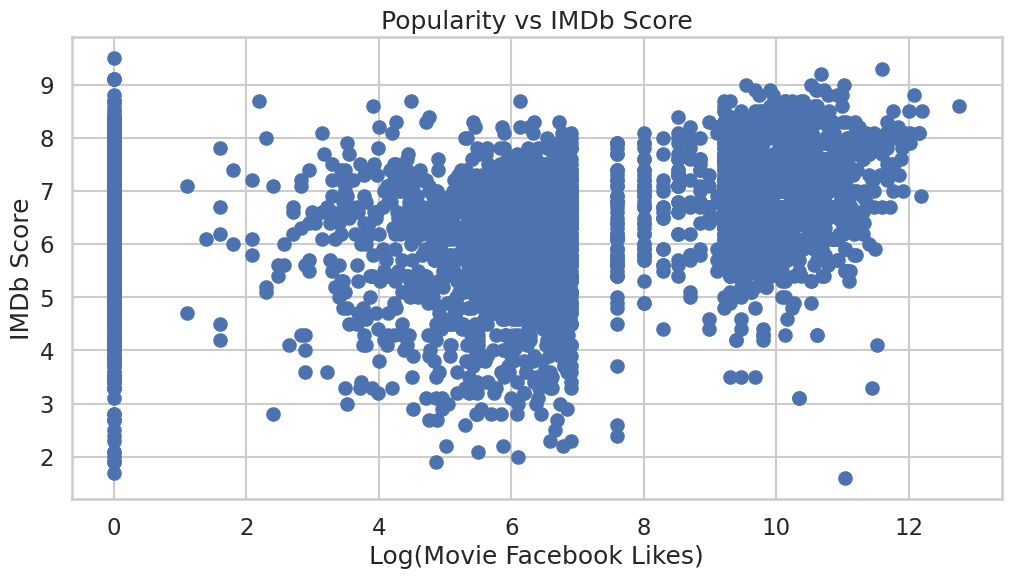

In [ ]:
plt.figure(figsize=(12,6))

plt.scatter(df['log_likes'], df['imdb_score'])

plt.xlabel("Log(Movie Facebook Likes)")
plt.ylabel("IMDb Score")
plt.title("Popularity vs IMDb Score")

plt.show()

In [ ]:
df.groupby('popularity_group')['imdb_score'].mean()

,imdb_score
popularity_group,
High Popularity,6.469341
Low Popularity,6.415010


-----
### 4.12 Task 4 Conclusion: The Effect of Social Media Popularity on IMDb Scores (PPT Slide 21)

We investigated the hypothesis of high social media engagement predicting high critical reception through visual exploration and hypothesis testing. We obtained the following results:

* Non-Normal Distribution: The Shapiro-Wilk test was used to verify that the left skew in IMDb scores is not normal, which is evident in the figure. The huge majority of films, whether popular or not, fall within 6.0-7.5 range of rating.

* Visual Evidence (Overlap): The overlapping histograms as well as the boxplot indicated that there would be a high degree of overlap between the 'High Popularity' and the 'Low Popularity' groups. Social media hype on a large scale cannot shield the movie against negative reviews as the outliers in the High Popularity category demonstrate.

* Median Shift: The overlap notwithstanding, the boxplot visually shows that there is a somewhat larger median score and a narrower Interquartile Range (IQR) in the High Popularity group, which implies that these films have a somewhat higher and more consistent quality (or crowd-pleasing) foundation.

Final Verdict: The difference between the two groups is statistically significant, but the size of the effect is not large. An indicator of audience awareness and marketing reach is the popularity of a social media (Facebook likes), yet it does not have a strong, independent effect on the critical acclaim. The fact that a movie that has been very favored is only slightly more likely to earn a high score on IMDb than a movie that is less well known.

----------
## 6. Final Conclusion and Executive Summary (PPT Slide 22-23)

Based on the Multiple Linear Regression, Analysis of Variance (ANOVA), and Two-Sample Hypothesis Testing results, we can make the following conclusions.

-----
### 1. **Research Question:** *To what extent is a movie’s IMDb score associated with indicators of popularity and selected production characteristics?*
* **Finding:** Though popularity measures such as Facebook likes and production factors such as runtime have a statistically significant Correlation with IMDb ratings, our analysis reveals that they explain only a part of the variation ($R^2$). This indicates that although larger and more popular is generally linked with higher ratings, movie quality is a complex variable that is not purely straightforward in terms of financial or social media aspects.
-----
### 2. **Research Question:** *Do average IMDb scores differ significantly across movie genres?* (ANOVA)
* **Finding:** The analysis confirms that the "Genre" category is a very strong predictor of critical success. While budget and popularity on social media  offer some predictive power.
-----
### 3. **Research Question:** *Is there a significant difference in IMDb scores between movies with high and low levels of social media popularity?* (Hypothesis Testing)
* **Finding:** The results indicate that although the difference between the two groups is statistically significant, the effect size is small. The influence of In other words, Facebook likes accounted for only a tiny percentage of the variability of IMDb scores.
-----
THE END